# Bregman Flow and Mirror Descent

We show KL-Bregman geometry and mirror descent for a linear objective on the simplex.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

y_ref = np.array([0.55, 0.30, 0.15])
y_ref = y_ref / y_ref.sum()

def kl(x, y):
    x = np.clip(x, 1e-12, None); y = np.clip(y, 1e-12, None)
    return np.sum(x*np.log(x/y) - x + y)

# simplex grid x1+x2+x3=1, x3>=0
r = 170
x1 = np.linspace(0.001, 0.998, r)
x2 = np.linspace(0.001, 0.998, r)
X1, X2 = np.meshgrid(x1, x2)
X3 = 1 - X1 - X2
mask = X3 > 0
Z = np.full_like(X1, np.nan)
for i in range(r):
    for j in range(r):
        if mask[i, j]:
            x = np.array([X1[i, j], X2[i, j], X3[i, j]])
            Z[i, j] = kl(x, y_ref)  # exactly zero at y_ref


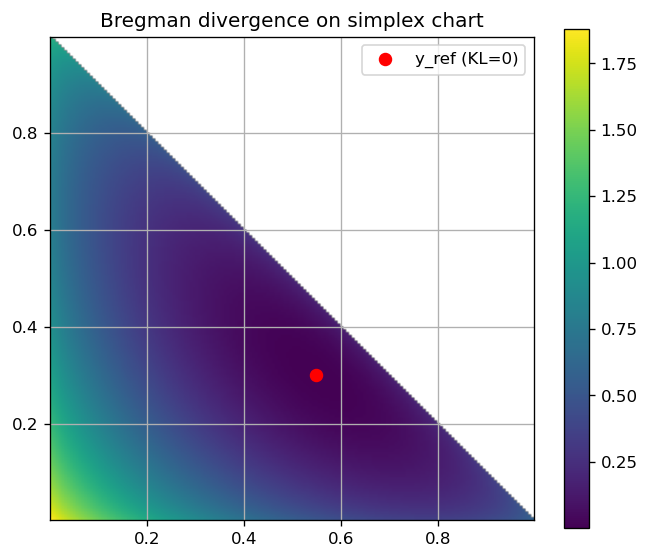

In [2]:
fig, ax = plt.subplots(figsize=(6.5, 5.4))
im = ax.imshow(Z, origin='lower', cmap='viridis', extent=[x1.min(),x1.max(),x2.min(),x2.max()])
ax.scatter([y_ref[0]], [y_ref[1]], c='r', s=50, label='y_ref (KL=0)')
ax.set_title('Bregman divergence on simplex chart')
ax.legend()
fig.colorbar(im, ax=ax)
plt.show()


## Mirror descent on a 2D linear objective


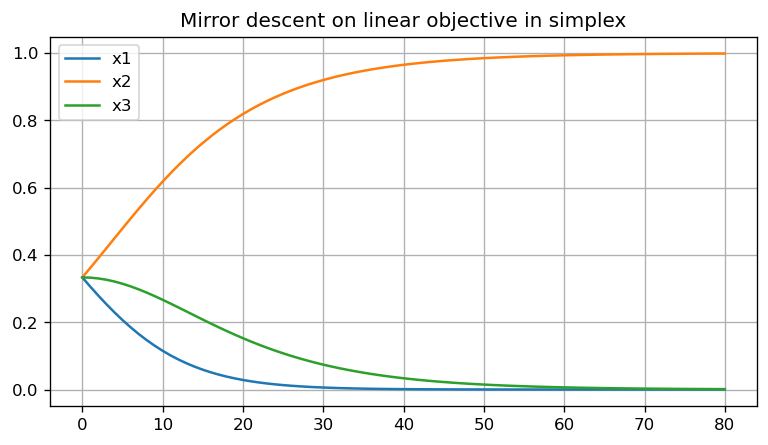

In [3]:
# linear objective c^T x on simplex
c = np.array([1.2, -0.2, 0.5])
x = np.array([1/3, 1/3, 1/3], dtype=float)
traj = [x.copy()]
eta = 0.12
for _ in range(80):
    x = x * np.exp(-eta * c)
    x = x / x.sum()
    traj.append(x.copy())
traj = np.array(traj)

fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.plot(traj[:,0], label='x1'); ax.plot(traj[:,1], label='x2'); ax.plot(traj[:,2], label='x3')
ax.set_title('Mirror descent on linear objective in simplex')
ax.legend()
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
